# Forward vs recurrent connectivity current contribution

This notebook calculates the mean absolute current input to the model units for the feedforward compared to the recurrent connections (Supplementary Figure 2).

In [5]:
import os
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

In [7]:
encoding_current_df = analysis.FeedforwardVsRecurrentContribution.get_df(root, prediction_offset=0)
prediction_current_df = analysis.FeedforwardVsRecurrentContribution.get_df(root, prediction_offset=128)

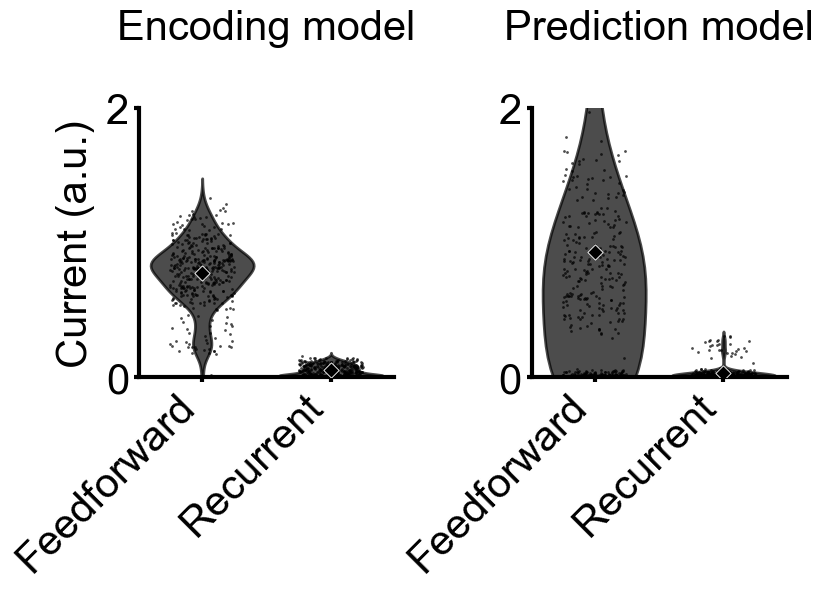

In [26]:
def plot_current_contribution(data_df, y_label, yticks, palette, ax):
    #sns.barplot(data_df, errorbar=("se"), errwidth=6, palette=palette, ax=ax)
        # Raw datapoints (draw FIRST → behind violins)
    data_df = data_df.melt(var_name="type", value_name="y")

    
    # Raw datapoints
    sns.stripplot(
        data=data_df,
        x="type",
        y="y",
        ax=ax,
        color="black",
        size=2,
        jitter=0.25,
        alpha=0.25,
        zorder=1
    )
    
    # Violin
    sns.violinplot(
        data=data_df,
        x="type",
        y="y",
        ax=ax,
        density_norm="width",
        inner=None,
        linewidth=2,
        palette=palette,
        zorder=2
    )

    
    # Make violins slightly transparent
    for pc in ax.collections:
        pc.set_alpha(0.7)
    
    # Mean
    means = data_df.groupby("type", as_index=False)["y"].mean()
    
    sns.scatterplot(
        data=means,
        x="type",
        y="y",
        ax=ax,
        color="black",
        marker="D",
        s=60,
        zorder=3
    )

    #ax.set_yscale("log")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs, rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=fs, labelpad=8)
    ax.set_ylim(0, yticks[-1])
    # ymin = data_df["y"][data_df["y"] > 0].min()
    # ymax = data_df["y"].max()
    # ax.set_ylim(ymin, ymax * 1.1)
    ax.set_yticks(yticks)
    
    ax.legend().set_visible(False)

fig, axs = plt.subplots(1, 2, figsize=(8, 6))
plot_current_contribution(encoding_current_df, "Current (a.u.)", [0, 2], ["black", "black"], ax=axs[0])
plot_current_contribution(prediction_current_df, "Current (a.u.)", [0, 2], ["black", "black"], ax=axs[1])
axs[1].set_ylabel("")
axs[0].set_title("Encoding model", fontsize=30, pad=50)
axs[1].set_title("Prediction model", fontsize=30, pad=50)
fig.tight_layout()
plt.savefig(f"{root}/figures/supp/current_contribution.svg", format="svg", transparent=False, bbox_inches="tight")

In [27]:
U1, p = mannwhitneyu(encoding_current_df["Feedforward"].values, encoding_current_df["Recurrent"].values, alternative="less")
print(p)
U1, p = mannwhitneyu(prediction_current_df["Feedforward"].values, prediction_current_df["Recurrent"].values, alternative="less")
print(p)

1.0
1.0


In [28]:
print(f"% contribution = {100*encoding_current_df['Recurrent'].mean() / (encoding_current_df['Recurrent'].mean() + encoding_current_df['Feedforward'].mean())}")

% contribution = 6.104019169194162


In [29]:
print(encoding_current_df.columns)
print((encoding_current_df["Feedforward"] <= 0).any())
print((encoding_current_df["Recurrent"] <= 0).any())
print(prediction_current_df.columns)
print((prediction_current_df["Feedforward"] <= 0).any())
print((prediction_current_df["Recurrent"] <= 0).any())

Index(['Feedforward', 'Recurrent'], dtype='object')
False
False
Index(['Feedforward', 'Recurrent'], dtype='object')
False
False


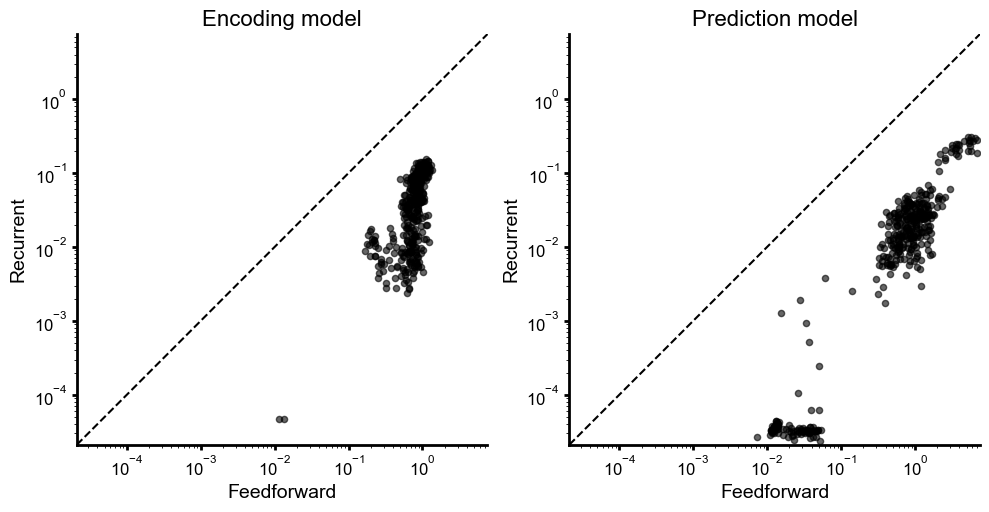

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute shared limits across both datasets ---
ff_all = np.concatenate([
    encoding_current_df["Feedforward"].values,
    prediction_current_df["Feedforward"].values
])

rec_all = np.concatenate([
    encoding_current_df["Recurrent"].values,
    prediction_current_df["Recurrent"].values
])

# Remove zeros (required for log scale)
mask = (ff_all > 0) & (rec_all > 0)
ff_all = ff_all[mask]
rec_all = rec_all[mask]

min_val = min(ff_all.min(), rec_all.min())
max_val = max(ff_all.max(), rec_all.max())

# Optional padding
min_val *= 0.9
max_val *= 1.1


# --- Plotting function ---
def plot_ff_vs_rec(data_df, title, ax, min_val, max_val):
    ff = data_df["Feedforward"].values
    rec = data_df["Recurrent"].values

    # Remove zeros for log scale
    mask = (ff > 0) & (rec > 0)
    ff = ff[mask]
    rec = rec[mask]

    # Scatter
    ax.scatter(ff, rec, s=20, alpha=0.6, color="black")

    # Log scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Identity line
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")

    # Shared limits
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    # Square axes
    ax.set_aspect("equal", adjustable="box")

    # Styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=12, width=2)

    ax.set_xlabel("Feedforward", fontsize=14)
    ax.set_ylabel("Recurrent", fontsize=14)
    ax.set_title(title, fontsize=16)


# --- Create figure ---
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

plot_ff_vs_rec(encoding_current_df, "Encoding model", axs[0], min_val, max_val)
plot_ff_vs_rec(prediction_current_df, "Prediction model", axs[1], min_val, max_val)

plt.tight_layout()
plt.savefig(f"{root}/figures/supp/current_scatter.svg", format="svg", bbox_inches="tight")